# 🛡️ Original strategy: crisis-aware IBS mean reversion

## 🧭 tl;dr

The Reddit IBS strategy produced a moderate but cost-sensitive result. This notebook builds an original risk filter around that idea: only enter short-term mean-reversion trades when SPY is above its long-term trend and volatility is not in an extreme state, then exit if the trend breaks or volatility spikes.

> Educational research only. Not financial advice. The filter may avoid some losses and also miss some of the best rebounds.

<div style="border-left: 5px solid #059669; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #ECFDF5; border-radius: 8px;"><strong>🧑‍🏫 Reader guide</strong><br>Compare the original mean-reversion signal with the filtered version across low-, medium-, and high-volatility regimes. The tradeoff is intentionally visible.</div>


## 💡 How the idea was built

Earlier research in this repository showed:

- IBS/lower-band mean reversion can produce a smoother path than buy and hold, but it has high turnover and its Sharpe falls after costs.
- Momentum and trend strategies often struggle at turning points but can reduce exposure during sustained declines.
- Volatility spikes are especially dangerous for short-horizon long mean-reversion trades.

**Original hypothesis:** mean reversion should be more reliable when the broad market is in a long-term uptrend and volatility is not extreme. A 200-day trend gate and VIX-based circuit breaker may improve the tradeoff even if the filter reduces opportunity.


In [1]:

from pathlib import Path
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    if (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    elif "__file__" in globals():
        ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import run_backtest, split_time_series
from src.data import load_price_data, load_price_panel, make_demo_ohlcv
from src.portfolio import run_portfolio_backtest
from src.research import metrics_for_period

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:

def load_spy_vix():
    try:
        spy = load_price_data("SPY", "1993-01-01", "2026-01-01")
        vix = load_price_data("^VIX", "1993-01-01", "2026-01-01")["close"].rename("VIX")
        data = spy.join(vix, how="inner")
        source = "Yahoo Finance adjusted SPY OHLCV plus ^VIX"
    except Exception as exc:
        spy = make_demo_ohlcv(periods=8_000, seed=1203, start="1993-01-01")
        realized = spy["close"].pct_change().rolling(21).std() * np.sqrt(252) * 100
        data = spy.join((realized + 12.0).clip(lower=10.0).rename("VIX"), how="inner")
        source = f"deterministic SPY/VIX fallback ({type(exc).__name__})"
    return data.dropna(subset=["close", "VIX"]), source


data, data_source = load_spy_vix()
print(f"Data source: {data_source}")
print(f"Observations: {len(data):,} | {data.index.min().date()} to {data.index.max().date()}")
display(data.head())


Data source: Yahoo Finance adjusted SPY OHLCV plus ^VIX
Observations: 8,288 | 1993-01-29 to 2025-12-31


,open,high,low,close,volume,VIX
Date,,,,,,
1993-01-29,24.130420,24.130420,24.010368,24.113270,1003200.0,12.42
1993-02-01,24.130419,24.284771,24.130419,24.284771,480500.0,12.33
1993-02-02,24.267607,24.353359,24.216157,24.336208,201300.0,12.25
1993-02-03,24.370520,24.610624,24.353370,24.593473,529400.0,12.12
1993-02-04,24.679223,24.747824,24.404819,24.696373,531500.0,12.29


## 📜 Exact rules

Both versions use the same Reddit-inspired entry:

- 25-day average high–low range.
- Lower band = 10-day rolling high − 2.5 × average range.
- IBS = `(close − low) / (high − low)`.
- Enter when close is below the lower band and IBS < 0.30.
- Exit when close is above yesterday’s high.

The **crisis-aware version** adds:

- Enter only when close is above its 200-day SMA and VIX < 30.
- Exit if close falls below its 200-day SMA or VIX rises above 35.

Signals are shifted by one bar and costs are charged on exposure changes.


In [3]:

def ibs_signal(data, crisis_aware=False):
    high, low, close, vix = data["high"], data["low"], data["close"], data["VIX"]
    average_range = (high - low).rolling(25, min_periods=25).mean()
    rolling_high = high.rolling(10, min_periods=10).max()
    lower_band = rolling_high - 2.5 * average_range
    ibs = ((close - low) / (high - low).replace(0.0, np.nan)).fillna(0.5)
    sma200 = close.rolling(200, min_periods=200).mean()
    target = pd.Series(0.0, index=close.index, name="target_position")
    state = 0.0
    for timestamp in close.index:
        base_entry = close.loc[timestamp] < lower_band.loc[timestamp] and ibs.loc[timestamp] < 0.30
        entry = base_entry
        if crisis_aware:
            entry = entry and close.loc[timestamp] > sma200.loc[timestamp] and vix.loc[timestamp] < 30.0
        exit_trade = close.loc[timestamp] > high.shift(1).loc[timestamp]
        if crisis_aware:
            exit_trade = exit_trade or close.loc[timestamp] < sma200.loc[timestamp] or vix.loc[timestamp] > 35.0
        if state == 0.0 and entry:
            state = 1.0
        elif state == 1.0 and exit_trade:
            state = 0.0
        target.loc[timestamp] = state
    diagnostics = pd.DataFrame({"close": close, "VIX": vix, "sma200": sma200, "lower_band": lower_band, "ibs": ibs, "target_position": target})
    return target, diagnostics


base_target, base_diag = ibs_signal(data, crisis_aware=False)
filtered_target, filtered_diag = ibs_signal(data, crisis_aware=True)
base = run_backtest(data["close"], base_target, transaction_cost_bps=10.0, benchmark_returns=data["close"].pct_change().fillna(0.0))
filtered = run_backtest(data["close"], filtered_target, transaction_cost_bps=10.0, benchmark_returns=data["close"].pct_change().fillna(0.0))
benchmark = run_backtest(data["close"], pd.Series(1.0, index=data.index), transaction_cost_bps=10.0)
splits = split_time_series(data[["close", "VIX"]])
periods = {name: frame.index for name, frame in splits.items()}


## 📈 Results: opportunity versus protection

In [4]:

rows = []
for name, backtest in [("Original IBS mean reversion", base), ("Crisis-aware IBS", filtered), ("SPY buy & hold", benchmark)]:
    for period_name, period_index in periods.items():
        metrics = metrics_for_period(backtest, period_index)
        rows.append({"strategy": name, "period": period_name, **metrics})
summary = pd.DataFrame(rows).set_index(["strategy", "period"])
display(summary[["annualized_return", "annualized_volatility", "sharpe_ratio", "sortino_ratio", "max_drawdown", "calmar_ratio", "win_rate", "annualized_turnover", "number_of_trades", "total_return_after_costs"]].style.format({"annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}", "sharpe_ratio": "{:.2f}", "sortino_ratio": "{:.2f}", "max_drawdown": "{:.2%}", "calmar_ratio": "{:.2f}", "win_rate": "{:.2%}", "annualized_turnover": "{:.2f}", "number_of_trades": "{:.0f}", "total_return_after_costs": "{:.2%}"}))


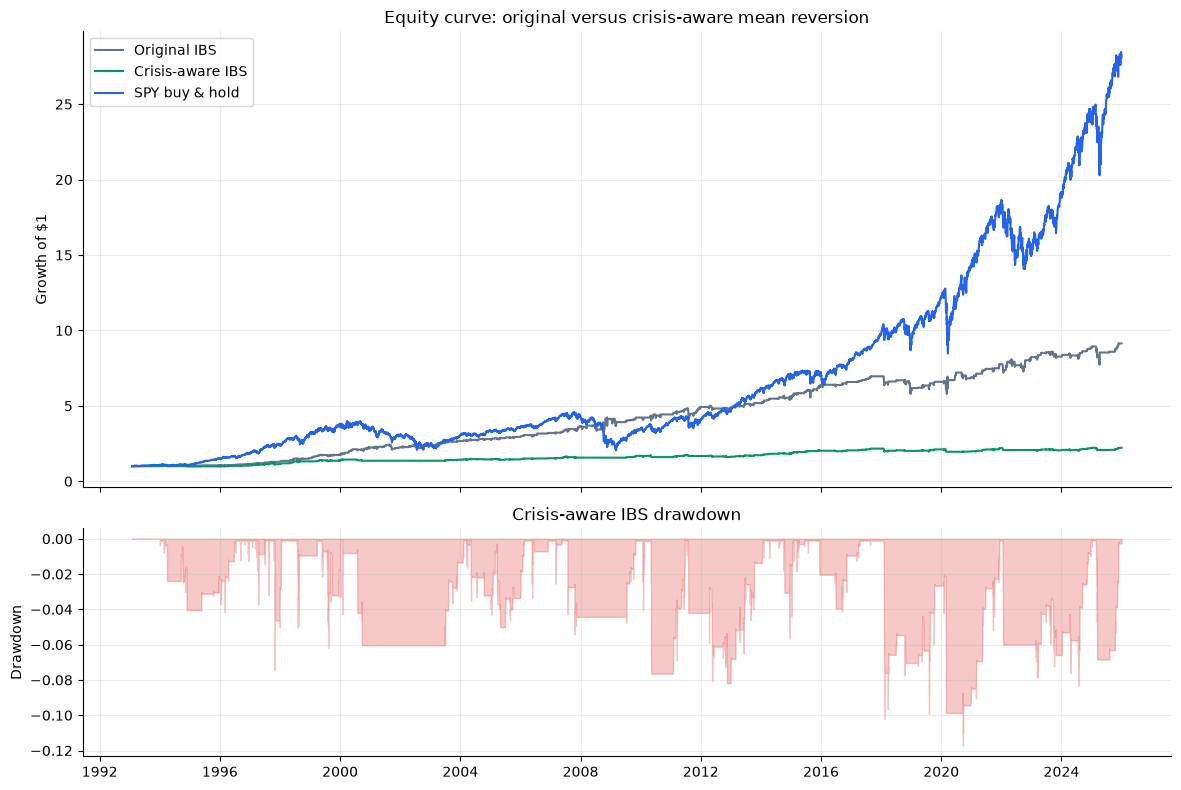

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for backtest, label, color in [(base, "Original IBS", "#64748B"), (filtered, "Crisis-aware IBS", "#059669"), (benchmark, "SPY buy & hold", "#2563EB")]:
    axes[0].plot(backtest.frame.index, backtest.frame.equity / backtest.frame.equity.iloc[0], label=label, color=color)
axes[0].set_title("Equity curve: original versus crisis-aware mean reversion")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[1].fill_between(filtered.frame.index, filtered.drawdown, 0, color="#DC2626", alpha=0.25)
axes[1].set_title("Crisis-aware IBS drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()


## 🌡️ Volatility regimes and stress windows

The regime table is descriptive. The thresholds are chosen before reading the resulting table because the strategy is specifically designed around volatility states.


In [6]:

regime_masks = {
    "low VIX (<20)": data["VIX"] < 20,
    "medium VIX (20–30)": data["VIX"].between(20, 30, inclusive="left"),
    "high VIX (>=30)": data["VIX"] >= 30,
}
regime_rows = []
for regime, mask in regime_masks.items():
    index = data.index[mask]
    for name, backtest in [("Original IBS", base), ("Crisis-aware IBS", filtered), ("SPY buy & hold", benchmark)]:
        metrics = metrics_for_period(backtest, index)
        regime_rows.append({"regime": regime, "strategy": name, "return": metrics["total_return_after_costs"], "sharpe": metrics["sharpe_ratio"], "drawdown": metrics["max_drawdown"], "observations": len(index)})
display(pd.DataFrame(regime_rows).style.format({"return": "{:.2%}", "sharpe": "{:.2f}", "drawdown": "{:.2%}", "observations": "{:.0f}"}))


,regime,strategy,return,sharpe,drawdown,observations
0,low VIX (<20),Original IBS,388.36%,1.61,-4.24%,5139
1,low VIX (<20),Crisis-aware IBS,212.45%,1.30,-5.00%,5139
2,low VIX (<20),SPY buy & hold,50921.57%,2.89,-7.58%,5139
3,medium VIX (20–30),Original IBS,151.64%,0.90,-27.40%,2446
4,medium VIX (20–30),Crisis-aware IBS,-4.38%,-0.03,-33.13%,2446
5,medium VIX (20–30),SPY buy & hold,-47.24%,-0.23,-63.43%,2446
6,high VIX (>=30),Original IBS,-25.63%,-0.21,-36.78%,703
7,high VIX (>=30),Crisis-aware IBS,-25.71%,-1.27,-24.20%,703
8,high VIX (>=30),SPY buy & hold,-89.56%,-1.70,-90.24%,703


In [7]:

stress_rows = []
for label, (start, end) in {"2008 crisis": ("2008-01-01", "2009-12-31"), "2020 shock": ("2020-02-01", "2020-06-30"), "2022 inflation": ("2022-01-01", "2022-12-31")}.items():
    index = data.loc[start:end].index
    for name, backtest in [("Original IBS", base), ("Crisis-aware IBS", filtered), ("SPY buy & hold", benchmark)]:
        metrics = metrics_for_period(backtest, index)
        stress_rows.append({"window": label, "strategy": name, "return": metrics["total_return_after_costs"], "sharpe": metrics["sharpe_ratio"], "drawdown": metrics["max_drawdown"]})
display(pd.DataFrame(stress_rows).style.format({"return": "{:.2%}", "sharpe": "{:.2f}", "drawdown": "{:.2%}"}))


,window,strategy,return,sharpe,drawdown
0,2008 crisis,Original IBS,15.41%,0.42,-23.75%
1,2008 crisis,Crisis-aware IBS,7.43%,1.24,-0.67%
2,2008 crisis,SPY buy & hold,-20.14%,-0.15,-51.87%
3,2020 shock,Original IBS,11.23%,0.97,-12.79%
4,2020 shock,Crisis-aware IBS,-5.91%,-1.61,-8.01%
5,2020 shock,SPY buy & hold,-3.17%,0.08,-33.72%
6,2022 inflation,Original IBS,6.04%,0.54,-10.12%
7,2022 inflation,Crisis-aware IBS,-5.90%,-1.99,-5.90%
8,2022 inflation,SPY buy & hold,-18.18%,-0.71,-24.50%


In [8]:

cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    cost_result = run_backtest(data["close"], filtered_target, transaction_cost_bps=cost_bps, benchmark_returns=data["close"].pct_change().fillna(0.0))
    metrics = metrics_for_period(cost_result, periods["test"])
    cost_rows.append({"transaction_cost_bps": cost_bps, "test_return": metrics["annualized_return"], "test_sharpe": metrics["sharpe_ratio"], "test_drawdown": metrics["max_drawdown"], "test_turnover": metrics["annualized_turnover"]})
display(pd.DataFrame(cost_rows).style.format({"test_return": "{:.2%}", "test_sharpe": "{:.2f}", "test_drawdown": "{:.2%}", "test_turnover": "{:.2f}"}))


,transaction_cost_bps,test_return,test_sharpe,test_drawdown,test_turnover
0,0,2.72%,0.50,-9.37%,15.35
1,5,1.94%,0.36,-9.65%,15.35
2,10,1.16%,0.23,-9.92%,15.35
3,25,-1.15%,-0.17,-13.83%,15.35
4,50,-4.88%,-0.80,-30.97%,15.35


## ⚖️ What went well / what went wrong

### ✅ What went well

- The filter is economically motivated and easy to explain: avoid buying dips during a broken trend or an extreme volatility spike.
- The base and filtered rules share the same entry logic, so the impact of the risk filter is visible.
- Regime and stress tables show whether protection comes from genuinely different behavior or simply from staying in cash.

### ⚠️ What went wrong or remains uncertain

- Mean reversion can work precisely because volatility is high, so a VIX filter may remove profitable opportunities as well as dangerous ones.
- The 30/35 VIX thresholds are design choices and can be overfit.
- A 200-day trend gate reacts slowly and can miss fast recoveries.
- SPY’s long history and adjusted OHLC data do not capture exact close-to-next-open execution, spreads, or market impact.

**Bottom line:** crisis protection is a tradeoff, not a free overlay. The strategy is interesting only if its drawdown reduction is worth the return and opportunity cost.
